In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All libraries loaded!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries loaded!


In [2]:
df = pd.read_csv('Tweets.csv')

# Shape — write this number down for your resume
print("Dataset shape:", df.shape)

# Check sentiment distribution
print("\nSentiment counts:")
print(df['airline_sentiment'].value_counts())

Dataset shape: (14640, 15)

Sentiment counts:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


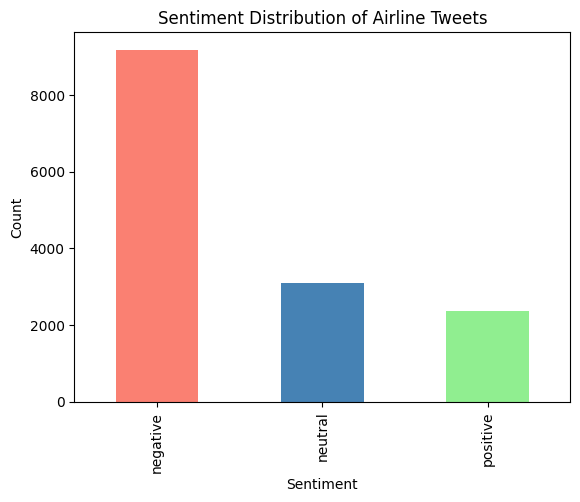

In [3]:
df['airline_sentiment'].value_counts().plot(kind='bar', color=['salmon', 'steelblue', 'lightgreen'])
plt.title('Sentiment Distribution of Airline Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.savefig('chart1_sentiment.png')
plt.show()

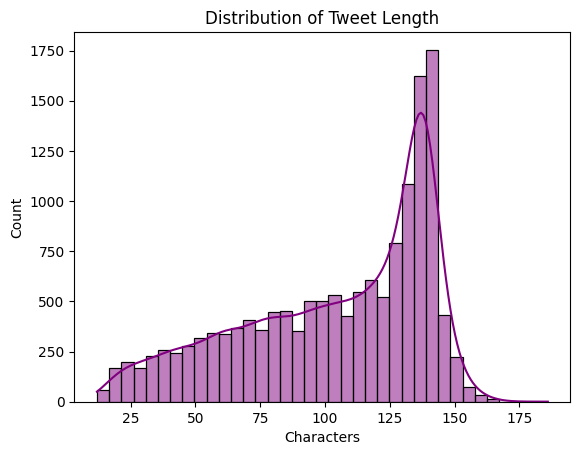

In [4]:
df['text_length'] = df['text'].apply(len)
sns.histplot(df['text_length'], kde=True, color='purple')
plt.title('Distribution of Tweet Length')
plt.xlabel('Characters')
plt.savefig('chart2_length.png')
plt.show()

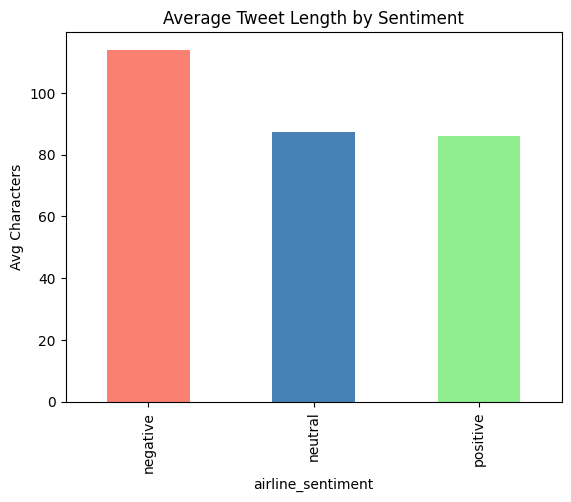

In [5]:
df.groupby('airline_sentiment')['text_length'].mean().plot(kind='bar', color=['salmon','steelblue','lightgreen'])
plt.title('Average Tweet Length by Sentiment')
plt.ylabel('Avg Characters')
plt.savefig('chart3_avg_length.png')
plt.show()

In [8]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text.strip()

In [9]:
df['clean_text'] = df['text'].apply(clean_text)

# Compare before and after
print("BEFORE:", df['text'][0])
print("\nAFTER:", df['clean_text'][0])

BEFORE: @VirginAmerica What @dhepburn said.

AFTER: said


In [10]:
# Convert sentiment labels to numbers
df['sentiment_label'] = df['airline_sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

# Split data into features and target
X = df['clean_text']
y = df['sentiment_label']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training set size:", X_train_tfidf.shape)
print("Test set size:", X_test_tfidf.shape)

Training set size: (11712, 5000)
Test set size: (2928, 5000)


In [11]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_predictions = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 79.88 %


In [12]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_predictions)
print("Naive Bayes Accuracy:", round(nb_accuracy * 100, 2), "%")

Naive Bayes Accuracy: 73.36 %


In [13]:
print("Classification Report — Logistic Regression:")
print(classification_report(y_test, lr_predictions, target_names=['negative', 'neutral', 'positive']))

Classification Report — Logistic Regression:
              precision    recall  f1-score   support

    negative       0.82      0.94      0.88      1889
     neutral       0.68      0.46      0.55       580
    positive       0.82      0.62      0.71       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.71      2928
weighted avg       0.79      0.80      0.79      2928



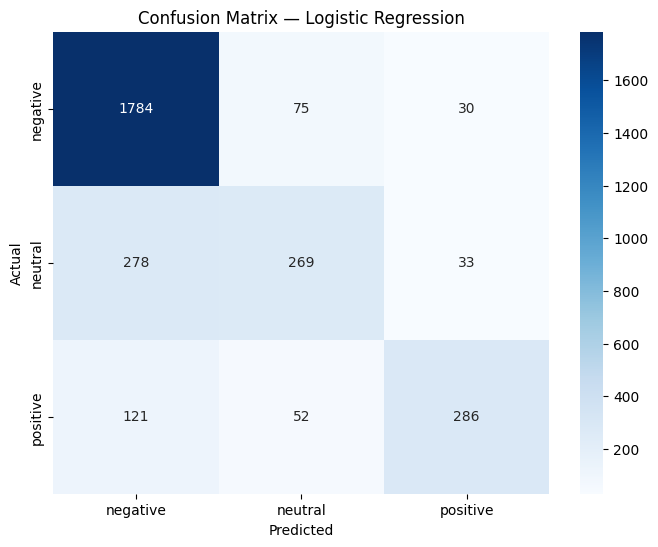

In [14]:
cm = confusion_matrix(y_test, lr_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('chart4_confusion_matrix.png')
plt.show()

/tmp/ipykernel_956/746913832.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette=['steelblue', 'salmon'])


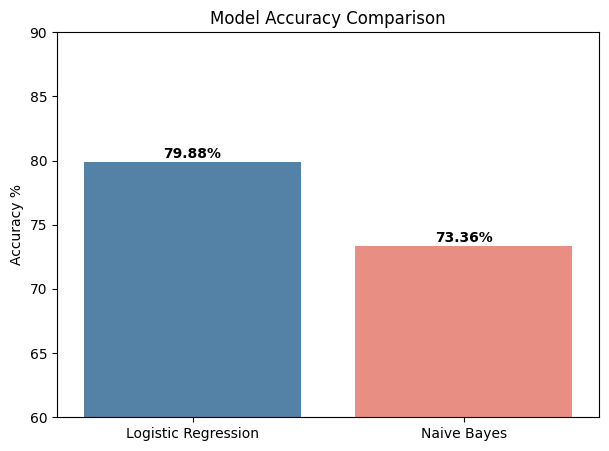

In [15]:
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [lr_accuracy * 100, nb_accuracy * 100]
plt.figure(figsize=(7,5))
sns.barplot(x=models, y=accuracies, palette=['steelblue', 'salmon'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy %')
plt.ylim(60, 90)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')
plt.savefig('chart5_accuracy.png')
plt.show()

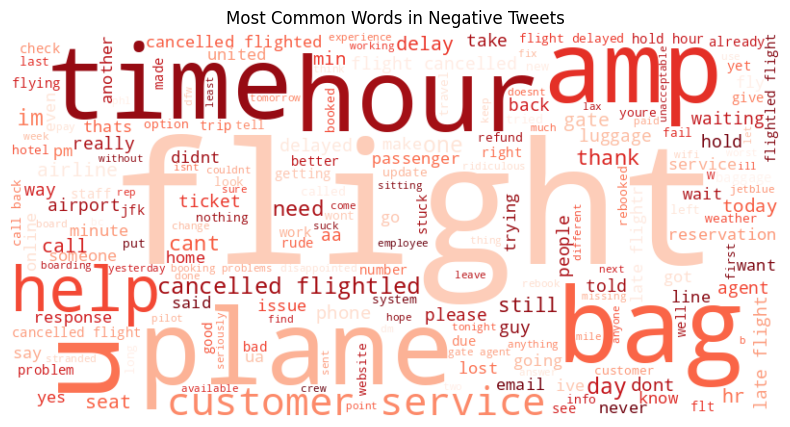

In [16]:
from wordcloud import WordCloud

negative_tweets = ' '.join(df[df['airline_sentiment'] == 'negative']['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_tweets)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Tweets')
plt.savefig('chart6_wordcloud.png')
plt.show()
